<a href="https://colab.research.google.com/github/RaGnaRoK260404/ds_UshnishChowdhury/blob/main/notebook_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
trader_file = 'historical_data.csv'
sentiment_file = 'fear_greed_index.csv'

try:
    trader_df = pd.read_csv(trader_file)
    sentiment_df = pd.read_csv(sentiment_file)
    print("Files loaded successfully!")
except FileNotFoundError:
    print(f"ERROR: Could not find files. Check names are '{trader_file}' and '{sentiment_file}'")

print("\n--- Cleaning Trader Data ---")
trader_df['datetime'] = pd.to_datetime(trader_df['Timestamp'], unit='ms')
trader_df['trade_date'] = trader_df['datetime'].dt.date
print("Trader data cleaned.")

print("\n--- Cleaning Sentiment Data ---")
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date
print("Sentiment data cleaned.")

print("\n--- Merging DataFrames ---")
merged_df = pd.merge(trader_df, sentiment_df, left_on='trade_date', right_on='date')
merged_df = merged_df.drop(columns=['date', 'timestamp'])
print("Data merged and cleaned successfully.")

print("\n--- Final Merged Data Head ---")
print(merged_df.head())

Files loaded successfully!

--- Cleaning Trader Data ---
Trader data cleaned.

--- Cleaning Sentiment Data ---
Sentiment data cleaned.

--- Merging DataFrames ---
Data merged and cleaned successfully.

--- Final Merged Data Head ---
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  

--- Unique Sentiment Categories ---
['Greed' 'Fear' 'Extreme Greed' 'Neutral']


--- Profitability Analysis ---
                   Total PnL  Average PnL per Trade
classification                                     
Extreme Greed   1.769655e+05              25.418772
Fear            6.699925e+06              50.047622
Greed           3.189617e+06              87.894859
Neutral         1.587424e+05              22.229713




/tmp/ipython-input-3286724862.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Chart saved as 'total_pnl_by_sentiment.png'


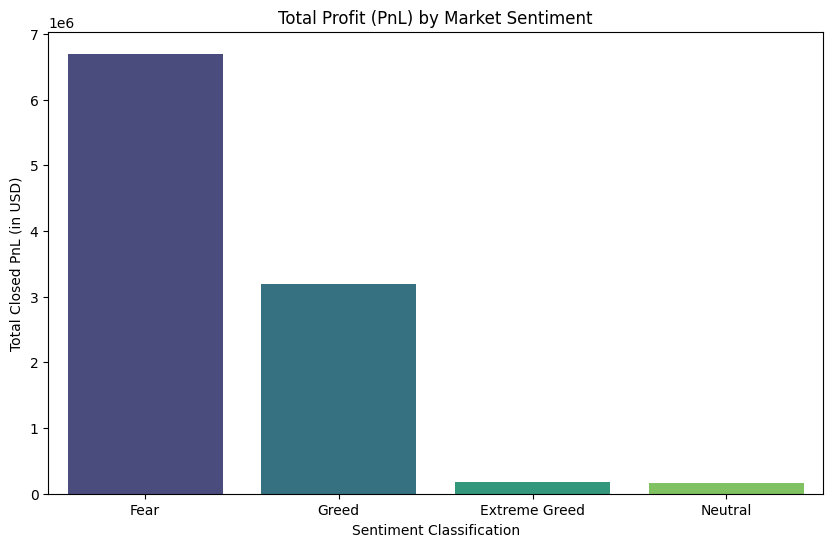

In [ ]:
print("--- Unique Sentiment Categories ---")
print(merged_df['classification'].unique())
print("\n")

profit_analysis = merged_df.groupby('classification')['Closed PnL'].agg(['sum', 'mean'])
profit_analysis.columns = ['Total PnL', 'Average PnL per Trade']

print("--- Profitability Analysis ---")
print(profit_analysis)
print("\n")

profit_analysis_sorted = profit_analysis.sort_values('Total PnL', ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x='classification',
    y='Total PnL',
    data=profit_analysis_sorted,
    palette='viridis'
)
plt.title('Total Profit (PnL) by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Total Closed PnL (in USD)')

plt.savefig('total_pnl_by_sentiment.png')
print("Chart saved as 'total_pnl_by_sentiment.png'")
plt.show()

--- Volume Analysis ---
                Number of Trades  Total USD Volume
classification                                    
Extreme Greed               6962      3.940677e+07
Fear                      133871      7.041585e+08
Greed                      36289      1.155037e+08
Neutral                     7141      2.184323e+07


Chart saved as 'total_volume_by_sentiment.png'


/tmp/ipython-input-1778127626.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


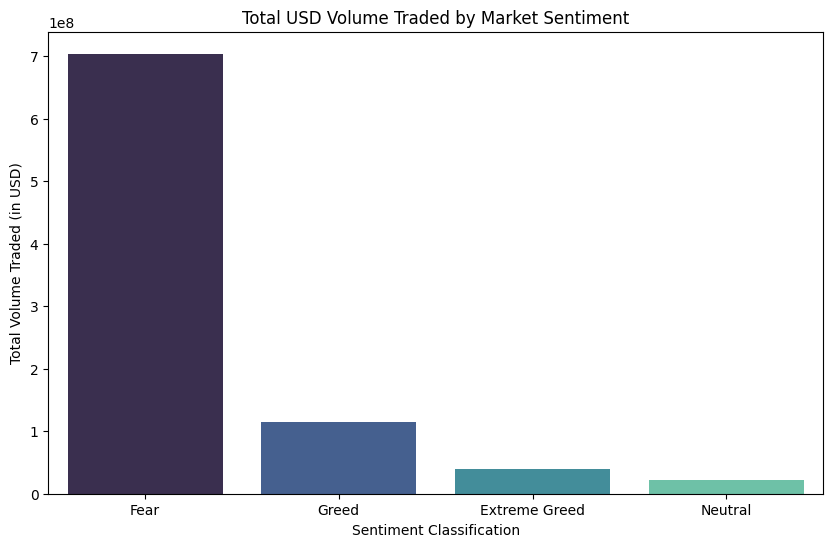

Chart saved as 'total_trades_by_sentiment.png'


/tmp/ipython-input-1778127626.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


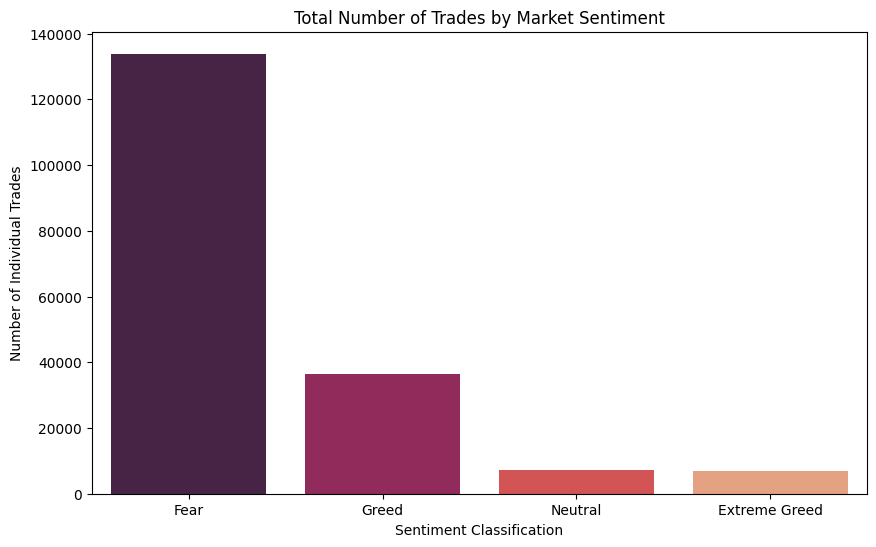

In [ ]:
volume_analysis = merged_df.groupby('classification')['Size USD'].agg(['count', 'sum'])
volume_analysis.columns = ['Number of Trades', 'Total USD Volume']

print("--- Volume Analysis ---")
print(volume_analysis)
print("\n")

volume_analysis_sorted_volume = volume_analysis.sort_values('Total USD Volume', ascending=False).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(
    x='classification',
    y='Total USD Volume',
    data=volume_analysis_sorted_volume,
    palette='mako'
)
plt.title('Total USD Volume Traded by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Total Volume Traded (in USD)')
plt.savefig('total_volume_by_sentiment.png')
print("Chart saved as 'total_volume_by_sentiment.png'")
plt.show()

volume_analysis_sorted_trades = volume_analysis.sort_values('Number of Trades', ascending=False).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(
    x='classification',
    y='Number of Trades',
    data=volume_analysis_sorted_trades,
    palette='rocket'
)
plt.title('Total Number of Trades by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Number of Individual Trades')
plt.savefig('total_trades_by_sentiment.png')
print("Chart saved as 'total_trades_by_sentiment.png'")
plt.show()

--- Analysis of Losing Trades ---
Average Loss per Trade:
classification
Neutral         -301.002712
Greed           -178.268548
Fear            -150.445182
Extreme Greed    -86.703571
Name: Closed PnL, dtype: float64


--- PnL Volatility (Standard Deviation) ---
classification
Greed            1148.343968
Fear              909.121796
Neutral           633.704815
Extreme Greed     306.166937
Name: Closed PnL, dtype: float64


Chart saved as 'average_loss_by_sentiment.png'


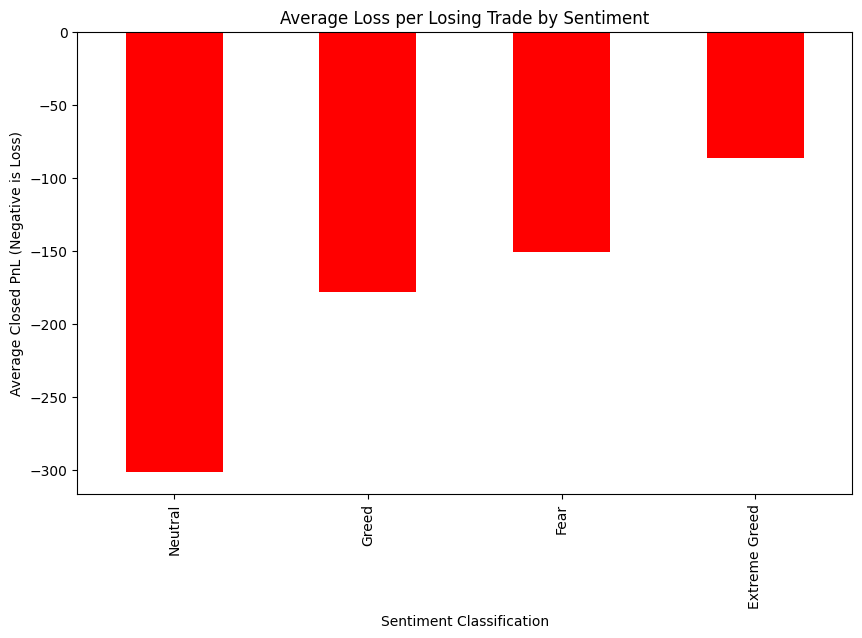

Chart saved as 'volatility_by_sentiment.png'


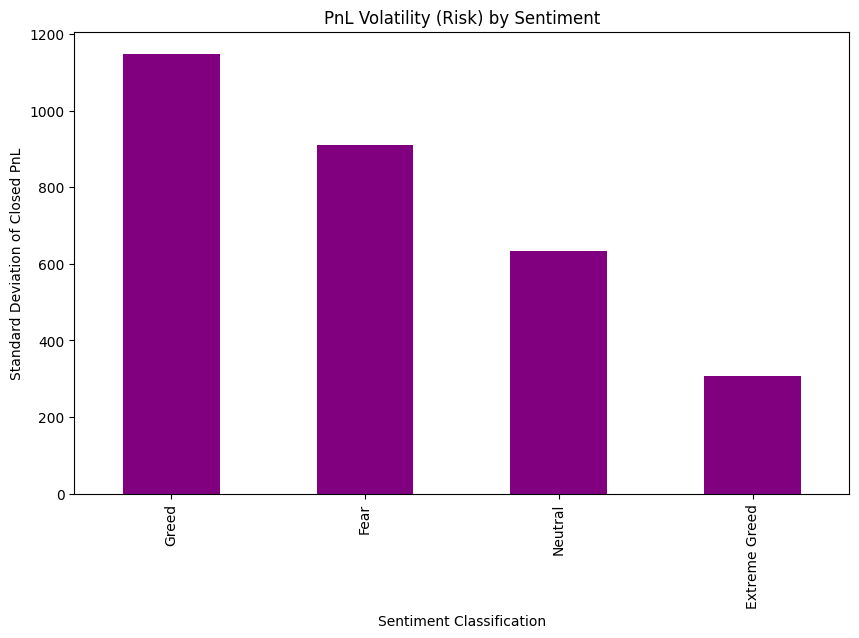

In [ ]:
losing_trades_df = merged_df[merged_df['Closed PnL'] < 0]

print("--- Analysis of Losing Trades ---")
average_loss = losing_trades_df.groupby('classification')['Closed PnL'].mean()
average_loss = average_loss.sort_values(ascending=True)
print("Average Loss per Trade:")
print(average_loss)
print("\n")

print("--- PnL Volatility (Standard Deviation) ---")
volatility = merged_df.groupby('classification')['Closed PnL'].std()
volatility = volatility.sort_values(ascending=False)
print(volatility)
print("\n")

plt.figure(figsize=(10, 6))
average_loss.plot(kind='bar', color='red')
plt.title('Average Loss per Losing Trade by Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Closed PnL (Negative is Loss)')
plt.savefig('average_loss_by_sentiment.png')
print("Chart saved as 'average_loss_by_sentiment.png'")
plt.show()

plt.figure(figsize=(10, 6))
volatility.plot(kind='bar', color='purple')
plt.title('PnL Volatility (Risk) by Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Standard Deviation of Closed PnL')
plt.savefig('volatility_by_sentiment.png')
print("Chart saved as 'volatility_by_sentiment.png'")
plt.show()